In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import plotly.graph_objects as go
import sys
sys.path.append("../")
from utils import metrics
from scipy import stats
from tqdm import tqdm
from background_removal.main_background_removal import main_background_removal

In [2]:
def compute_grad_magnitude(img):
    grad_x = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=1, dy=0)
    grad_y = cv2.Sobel(img, ddepth=cv2.CV_64F, dx=0, dy=1)
    grad_module = cv2.magnitude(grad_x, grad_y)
    return np.uint8(grad_module)

In [3]:
def get_discriminative_mask(img):
    hsv_image = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h, s, v = cv2.split(hsv_image)
    edges_s = compute_grad_magnitude(s)

    mask_s = edges_s
    mask_s[mask_s < 75] = 0
    mask_s[mask_s != 0] = 255

    mask = mask_s
    

    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(10, 5)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, ksize=(5, 10)))

    # plt.imshow(mask,cmap='gray')
    # plt.show()

    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

    #For each label except background, get area and pick the two largest (possible two paintings)
    component_info = [(i, stats[i, 4]) for i in range(1, num_labels)]
    component_info.sort(key=lambda c: c[1], reverse=True)
    top_two_labels = [c[0] for c in component_info[:2]]

    new_mask = np.zeros_like(mask)

    for label in top_two_labels:
        
        # Create a mask of only this component
        ys, xs = np.where(labels == label)
        points = np.column_stack((xs, ys))
        
        # Get rotated rectangle from these points
        rect = cv2.minAreaRect(points)
        box = cv2.boxPoints(rect).astype(int)
        
        # Fill the rectangle in the mask
        cv2.fillPoly(new_mask, [box], 255)
        
    # plt.imshow(new_mask,cmap='gray')
    # plt.show()  
    
    return new_mask

def get_masks(img) -> list:
    
    AREA_THRESHOLD = (0.2*img.shape[0]) * (0.2*img.shape[1])
    discriminative_mask = get_discriminative_mask(img)

    # Check if there is more than one painting (big area)
    num_labels, _, stats, _ = cv2.connectedComponentsWithStats(discriminative_mask)
    small_areas = np.sum(stats[1:, 4] < AREA_THRESHOLD)
    # print(num_labels - small_areas - 1)
    if num_labels - small_areas - 1 > 1:
        
        #Sort stats from left painting to right painting (in case there are more than 2 in the future)
        stats_no_background = stats[1:]
        stats_no_background = stats_no_background[np.argsort(stats_no_background[:, 0])]
        
        #Compute their distances to get their image slice
        left_painting_x = stats_no_background[0, 0] + stats_no_background[0, 2]
        right_painting_x = stats_no_background[1, 0]
        distance = right_painting_x - left_painting_x
        middle_pos = left_painting_x + distance//2

        
        left_painting = img[:, 0:middle_pos]
        right_painting = img[:, middle_pos:]
        
        _, left_mask = main_background_removal(left_painting)
        _, right_mask = main_background_removal(right_painting)
        return [left_mask, right_mask]

    # print("Doing single mask")
    # plt.imshow(img)
    # plt.show()
    _, mask = main_background_removal(img)
    return [mask]

In [4]:
def has_impulse_noise(img, diff_threshold=60, ratio_threshold=0.01):
    median = cv2.medianBlur(img, 3)
    diff = cv2.absdiff(img, median)
    noisy_pixels = np.any(diff > diff_threshold, axis=2)
    noise_ratio = np.sum(noisy_pixels) / noisy_pixels.size
    return noise_ratio > ratio_threshold

Hi Aleix
Hi Aleix


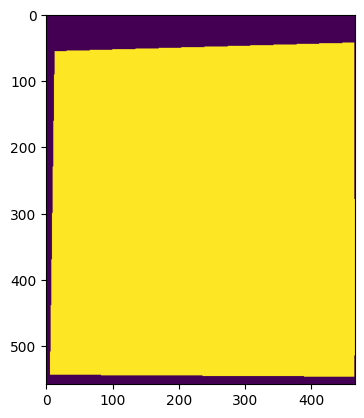

Hola


In [5]:
img1 = cv2.imread("../data/qsd2_w3/00022.jpg", cv2.IMREAD_UNCHANGED)
if has_impulse_noise(img1):
    img1 = cv2.medianBlur(img1, 3)
masks = get_masks(img1)
_, mask = main_background_removal(img1)
plt.imshow(mask)
plt.show()
print("Hola")

Hi Aleix
Hi Aleix


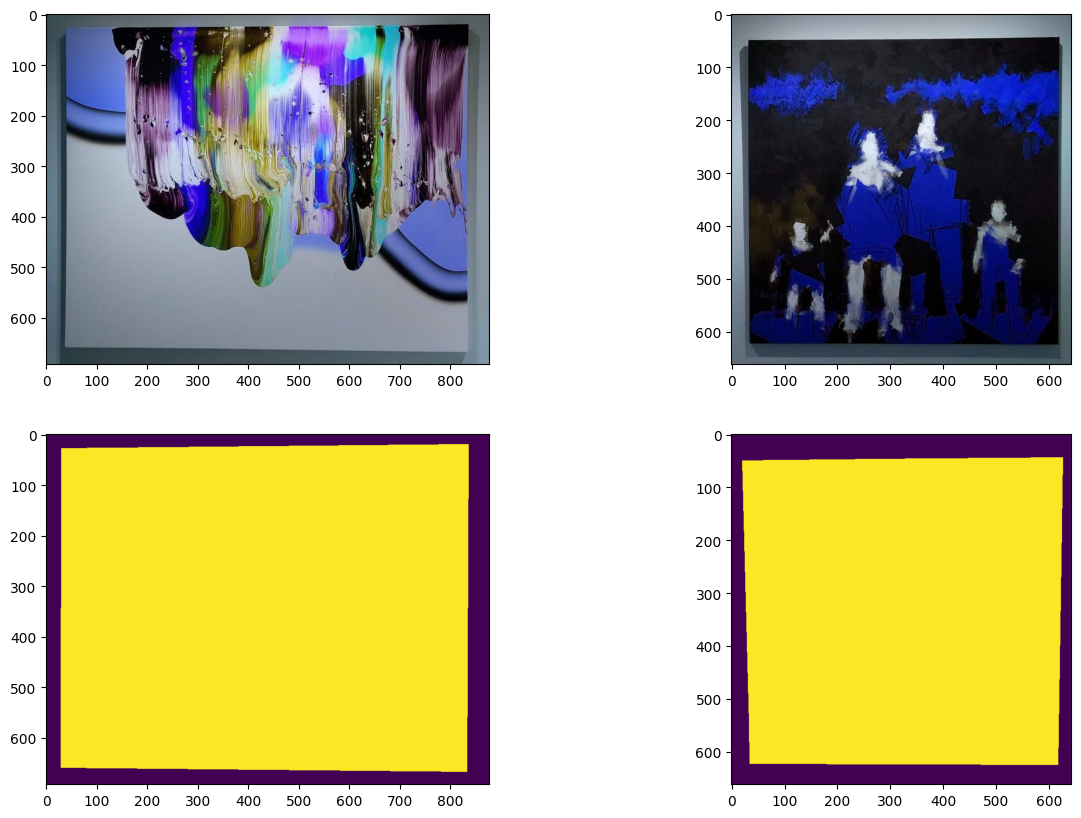

In [6]:
img1 = cv2.imread("../data/qsd2_w3/00021.jpg", cv2.IMREAD_UNCHANGED)
img2 = cv2.imread("../data/qsd2_w3/00009.jpg", cv2.IMREAD_UNCHANGED)
f, ax = plt.subplots(2, 2, figsize=(15,10))
ax[0][0].imshow(img1)
_, mask = main_background_removal(img1)
ax[1][0].imshow(mask)
ax[0][1].imshow(img2)
_, mask = main_background_removal(img2)
ax[1][1].imshow(mask)
plt.show()

  0%|          | 0/30 [00:00<?, ?it/s]

Hi Aleix


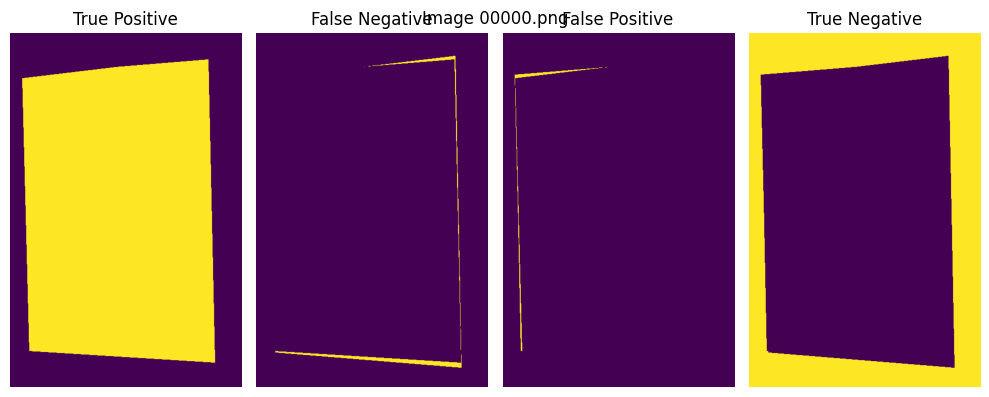

  3%|▎         | 1/30 [00:00<00:14,  2.05it/s]

Precision: 0.9926977475615608
Recall: 0.9819167833679521
F_score: 0.9872778346094874
Hi Aleix


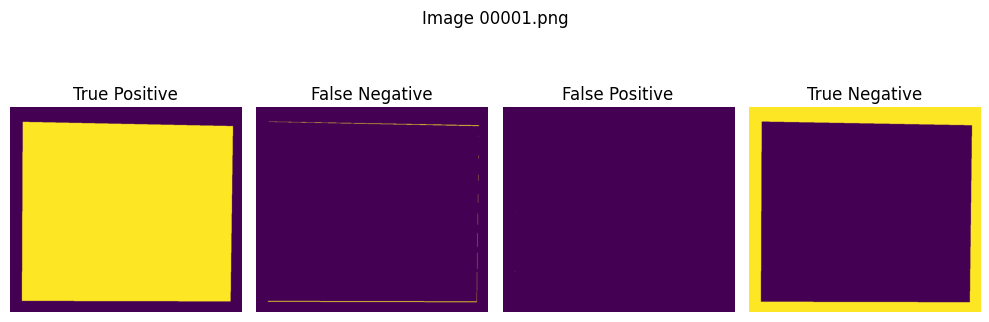

  7%|▋         | 2/30 [00:01<00:16,  1.73it/s]

Precision: 0.9999943398789489
Recall: 0.9919802510172073
F_score: 0.9959711743538188
Hi Aleix
Hi Aleix


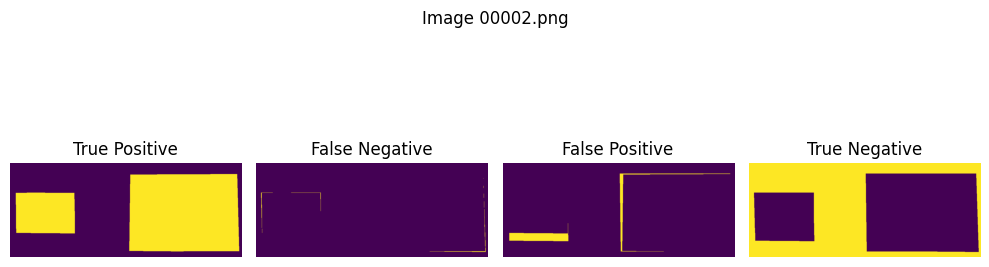

 10%|█         | 3/30 [00:01<00:14,  1.83it/s]

Precision: 0.934526252428247
Recall: 0.9925434288603593
F_score: 0.9626614957949088
Hi Aleix


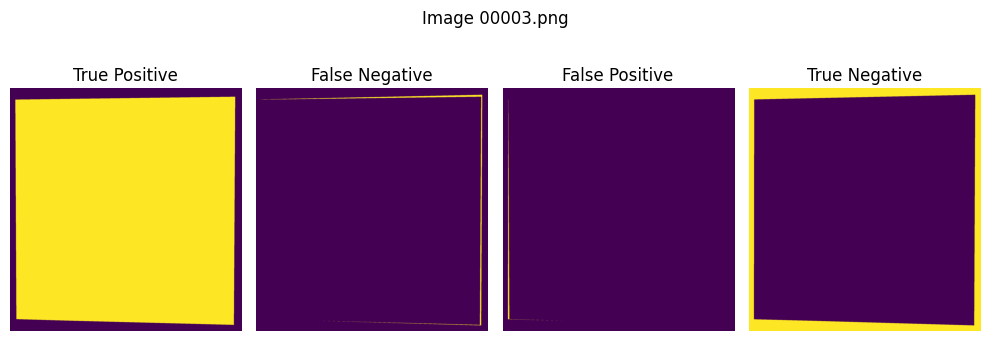

 13%|█▎        | 4/30 [00:04<00:35,  1.35s/it]

Precision: 0.9964017782861359
Recall: 0.9891807106233511
F_score: 0.9927781138448388
Hi Aleix


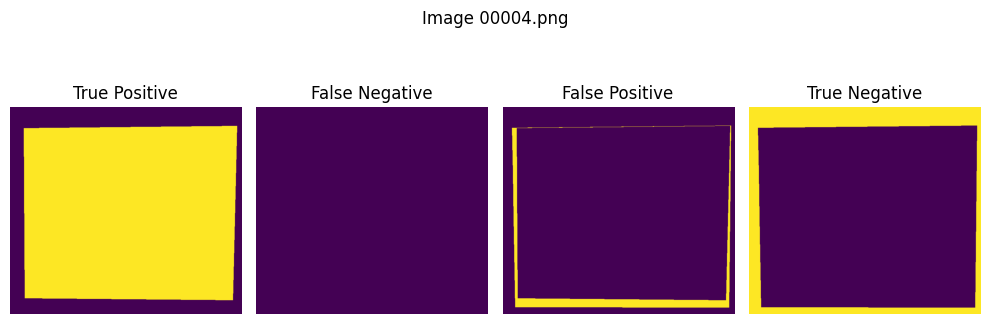

 17%|█▋        | 5/30 [00:04<00:25,  1.03s/it]

Precision: 0.9278147985163765
Recall: 1.0
F_score: 0.9625559459657762
Hi Aleix
Hi Aleix


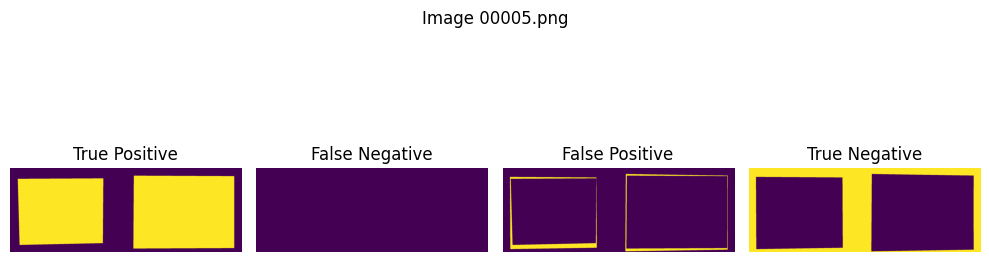

 20%|██        | 6/30 [00:06<00:28,  1.17s/it]

Precision: 0.9230629342906139
Recall: 1.0
F_score: 0.9599924348093335
Hi Aleix
Hi Aleix


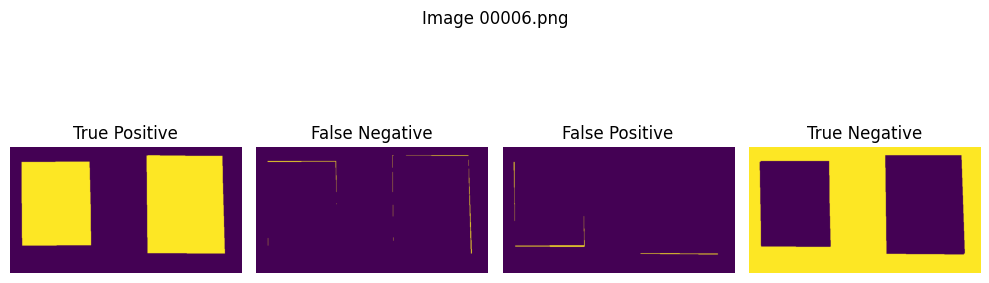

 23%|██▎       | 7/30 [00:06<00:21,  1.06it/s]

Precision: 0.9863076220903697
Recall: 0.9872771070993466
F_score: 0.9867921264745563
Hi Aleix
Hi Aleix


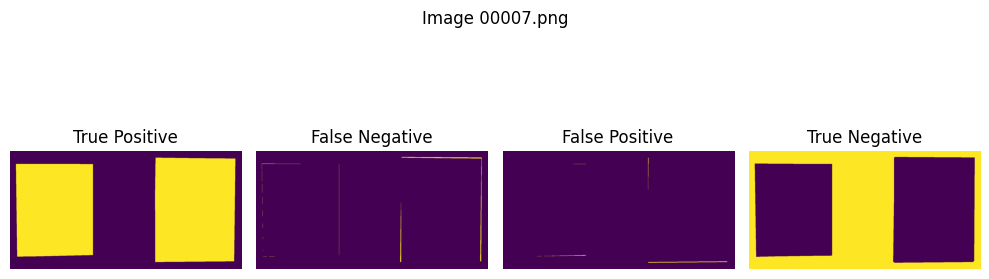

 27%|██▋       | 8/30 [00:07<00:21,  1.00it/s]

Precision: 0.9946339214518487
Recall: 0.9860009964262036
F_score: 0.9902986449229181
Hi Aleix
Hi Aleix


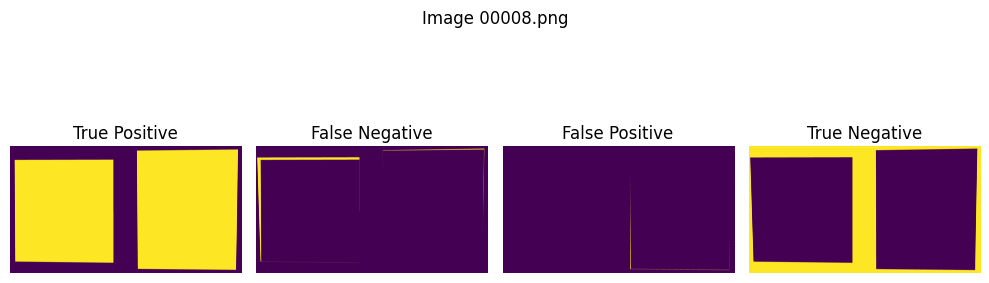

 30%|███       | 9/30 [00:14<01:00,  2.90s/it]

Precision: 0.9978070985252215
Recall: 0.9759744340972989
F_score: 0.9867700170722628
Hi Aleix


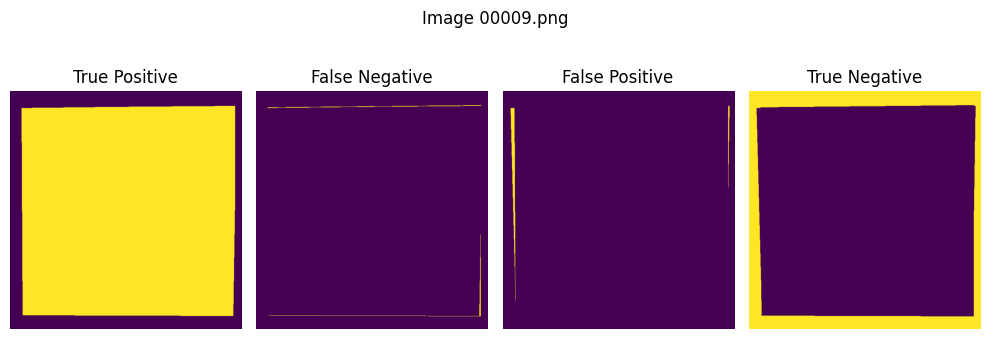

 33%|███▎      | 10/30 [00:15<00:43,  2.15s/it]

Precision: 0.99004399704749
Recall: 0.9938592678380247
F_score: 0.9919479638437226
Hi Aleix


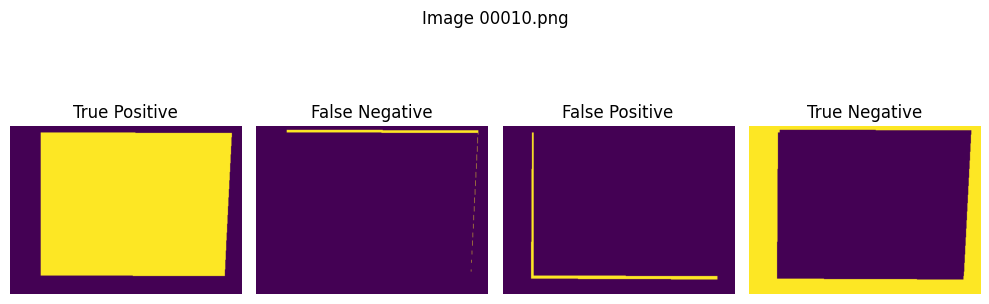

 37%|███▋      | 11/30 [00:15<00:29,  1.57s/it]

Precision: 0.9666322407136569
Recall: 0.9802208461316783
F_score: 0.9733791206873686
Hi Aleix
Hi Aleix


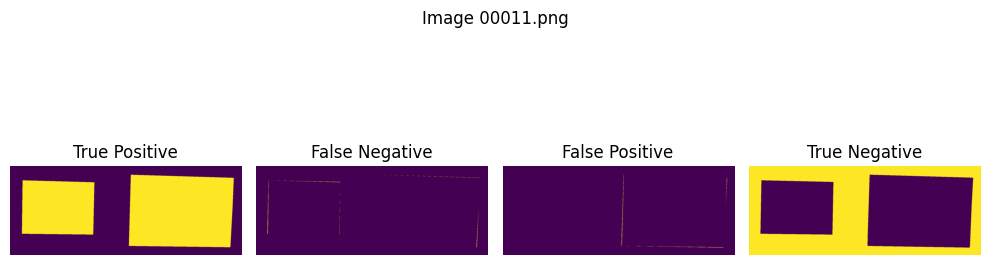

 40%|████      | 12/30 [00:16<00:24,  1.39s/it]

Precision: 0.9959586178034929
Recall: 0.9953386471620945
F_score: 0.9956485359719405
Hi Aleix
Hi Aleix


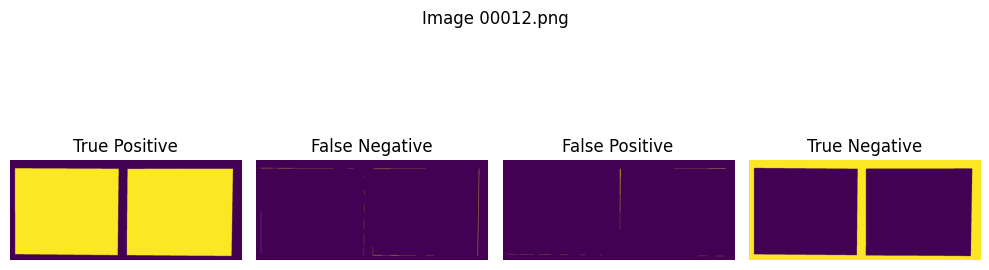

 43%|████▎     | 13/30 [00:17<00:20,  1.22s/it]

Precision: 0.9975977183759598
Recall: 0.9955632153671128
F_score: 0.9965794285202363
Hi Aleix


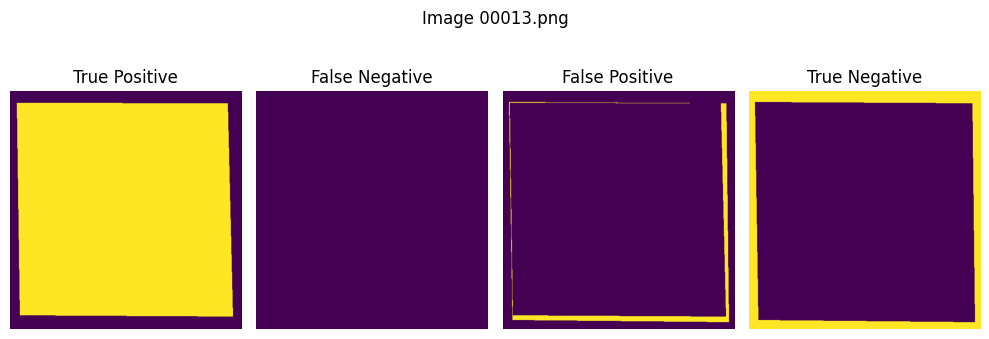

 47%|████▋     | 14/30 [00:17<00:15,  1.06it/s]

Precision: 0.9524371282035414
Recall: 1.0
F_score: 0.9756392300118665
Hi Aleix


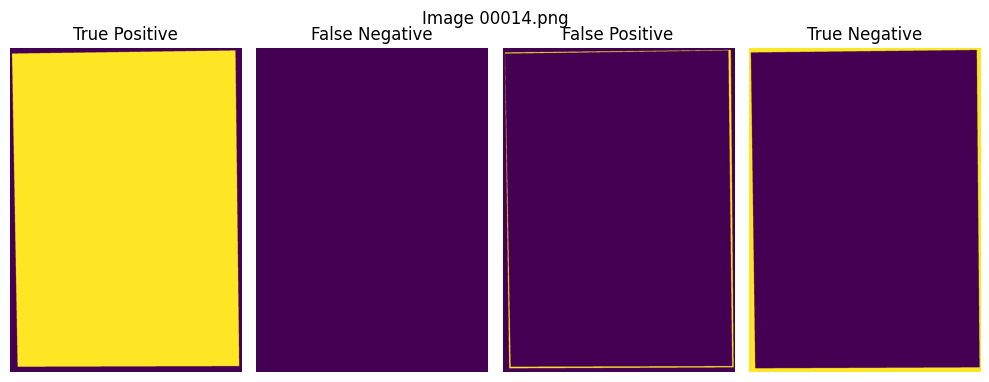

 50%|█████     | 15/30 [00:19<00:18,  1.22s/it]

Precision: 0.9815124257469333
Recall: 1.0
F_score: 0.9906699680441834
Hi Aleix


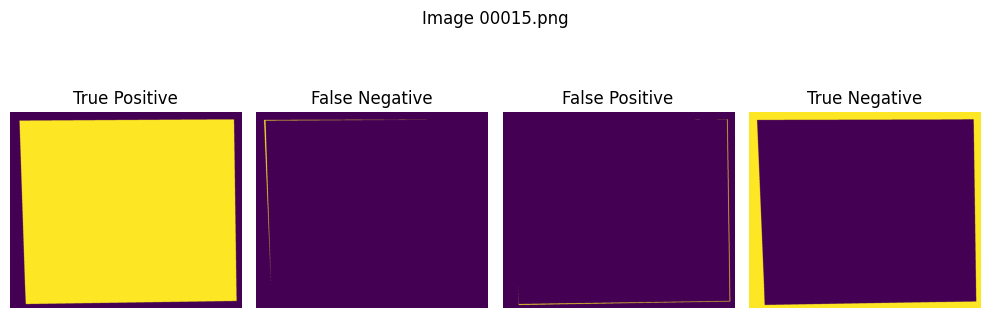

 53%|█████▎    | 16/30 [00:21<00:20,  1.48s/it]

Precision: 0.9933433776771473
Recall: 0.9955753388198008
F_score: 0.9944581058970078
Hi Aleix


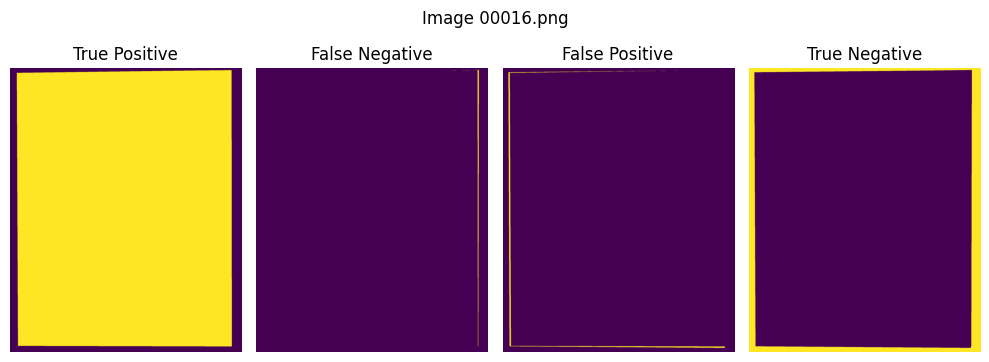

 57%|█████▋    | 17/30 [00:24<00:22,  1.76s/it]

Precision: 0.9892380204241948
Recall: 0.9959613514065939
F_score: 0.99258830086759
Hi Aleix


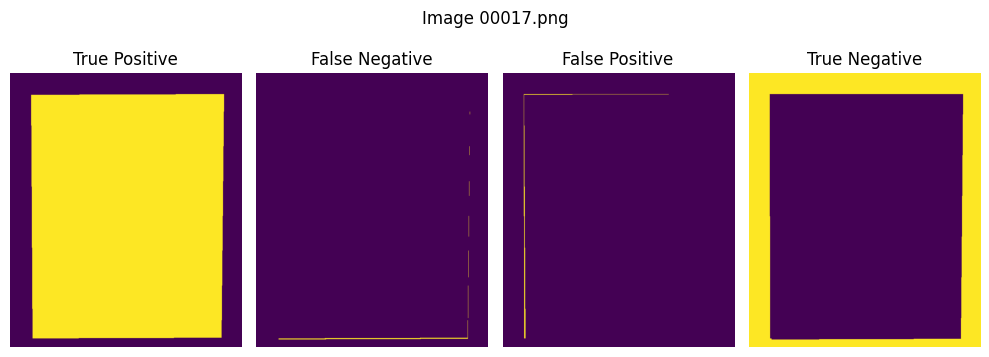

 60%|██████    | 18/30 [00:24<00:17,  1.42s/it]

Precision: 0.99388393405903
Recall: 0.9946963525121246
F_score: 0.9942899773320708
Hi Aleix


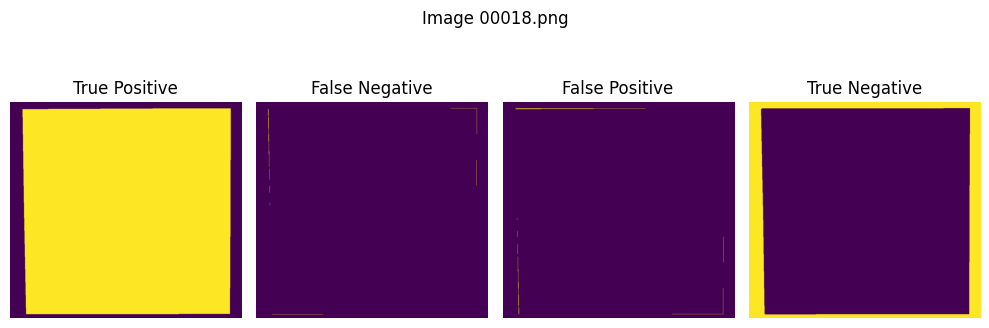

 63%|██████▎   | 19/30 [00:25<00:13,  1.19s/it]

Precision: 0.9973777241341282
Recall: 0.9985921843226382
F_score: 0.9979845847554911
Hi Aleix
Hi Aleix


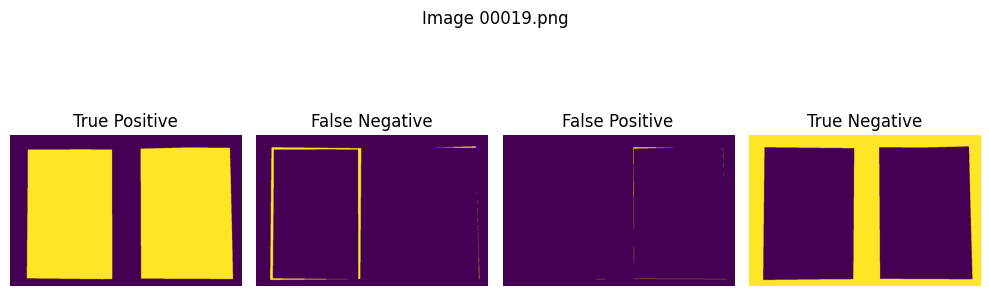

 67%|██████▋   | 20/30 [00:25<00:10,  1.05s/it]

Precision: 0.9962568569081417
Recall: 0.9607302804888697
F_score: 0.9781710991206644
Hi Aleix


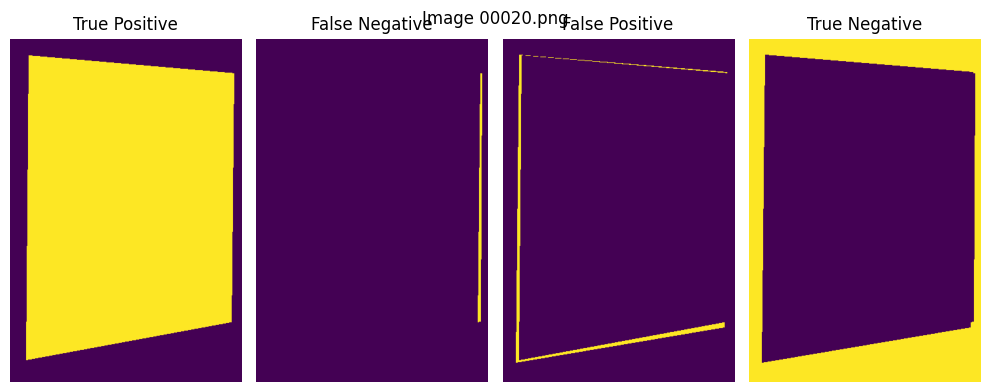

 70%|███████   | 21/30 [00:26<00:07,  1.23it/s]

Precision: 0.9695701333632973
Recall: 0.9889968193931058
F_score: 0.9791871314129273
Hi Aleix


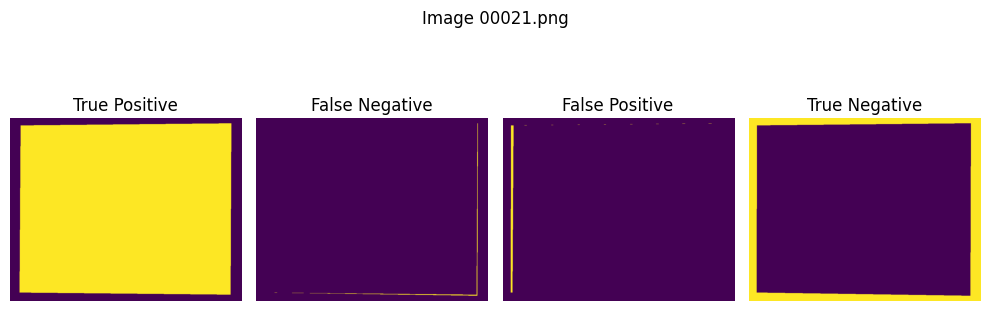

 73%|███████▎  | 22/30 [00:26<00:05,  1.38it/s]

Precision: 0.9894309494511031
Recall: 0.9938045483918686
F_score: 0.9916129264060267
Hi Aleix


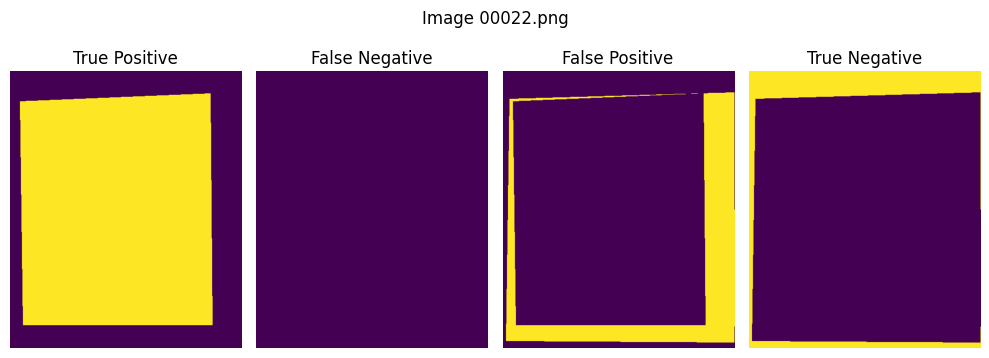

 77%|███████▋  | 23/30 [00:27<00:04,  1.68it/s]

Precision: 0.7755112870061244
Recall: 1.0
F_score: 0.8735639054300749
Hi Aleix


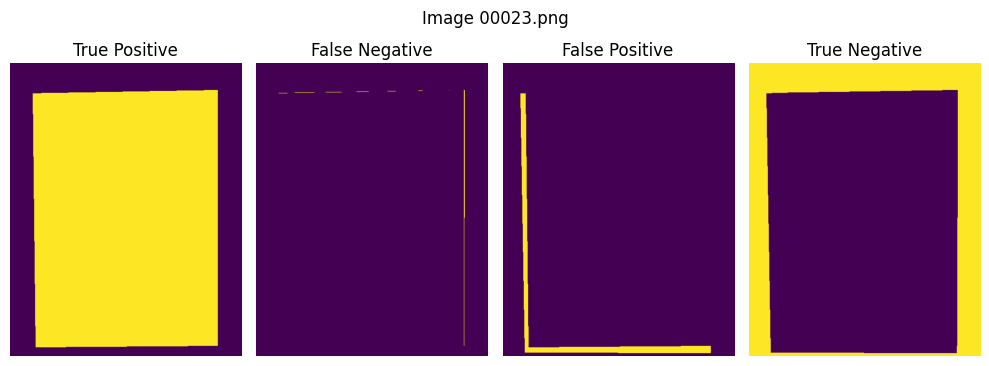

 80%|████████  | 24/30 [00:27<00:03,  1.93it/s]

Precision: 0.952356593773534
Recall: 0.9953468110805299
F_score: 0.973377256785181
Hi Aleix


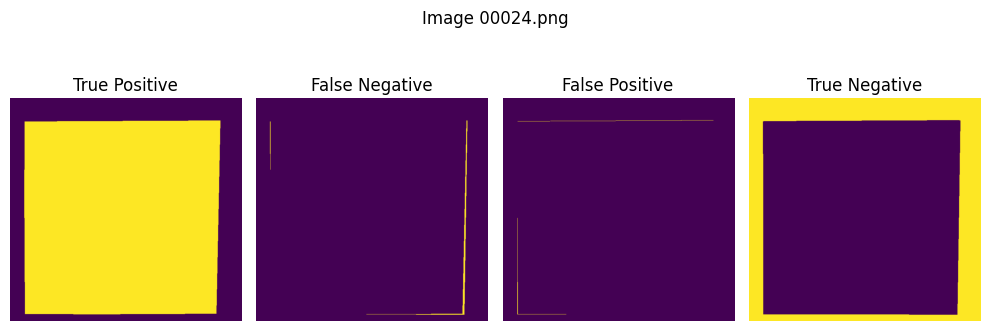

 83%|████████▎ | 25/30 [00:27<00:02,  1.90it/s]

Precision: 0.996715559272935
Recall: 0.9900447249200307
F_score: 0.9933689429519967
Hi Aleix


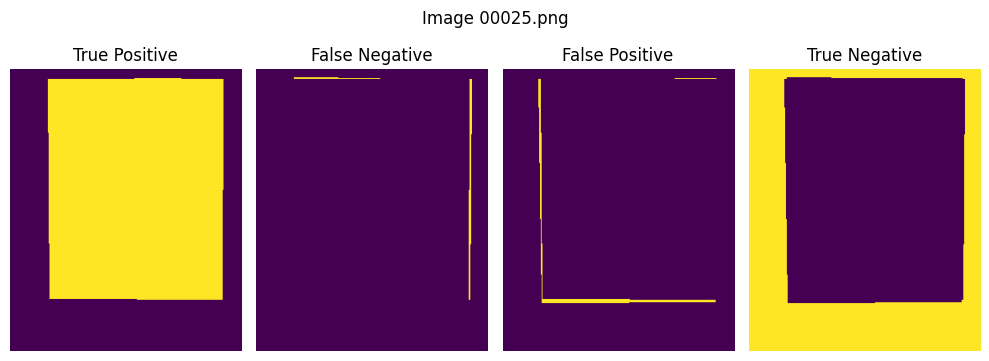

 87%|████████▋ | 26/30 [00:28<00:01,  2.24it/s]

Precision: 0.974686259787622
Recall: 0.985307671455679
F_score: 0.9799681863524844
Hi Aleix


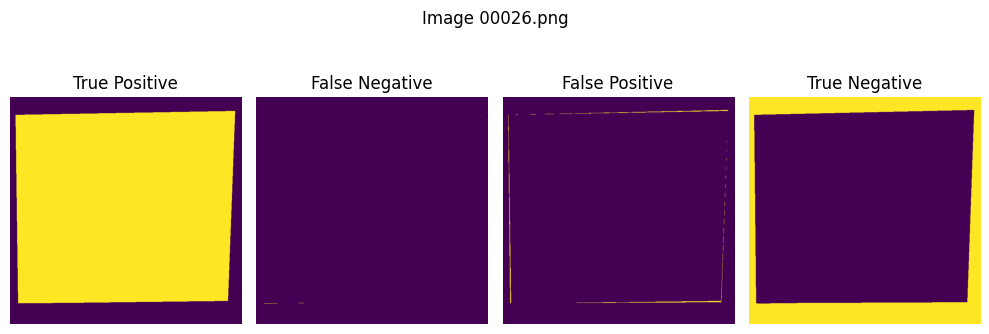

 90%|█████████ | 27/30 [00:28<00:01,  2.09it/s]

Precision: 0.9909742377931318
Recall: 0.9998471007450599
F_score: 0.995390896601544
Hi Aleix


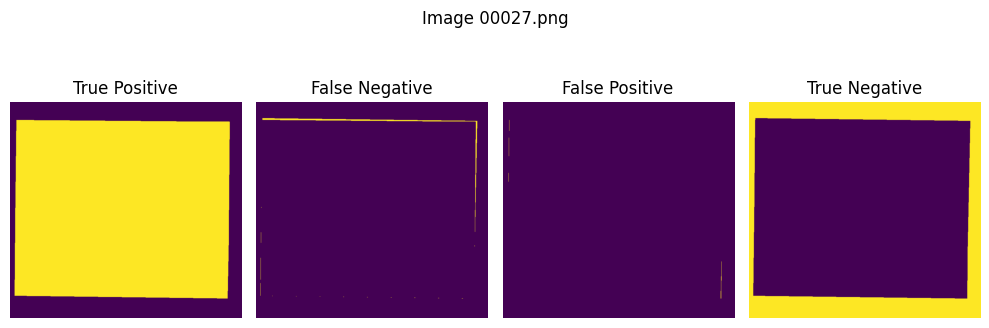

 93%|█████████▎| 28/30 [00:29<00:01,  1.98it/s]

Precision: 0.9992936340926152
Recall: 0.9894528032440916
F_score: 0.9943488711824268
Hi Aleix


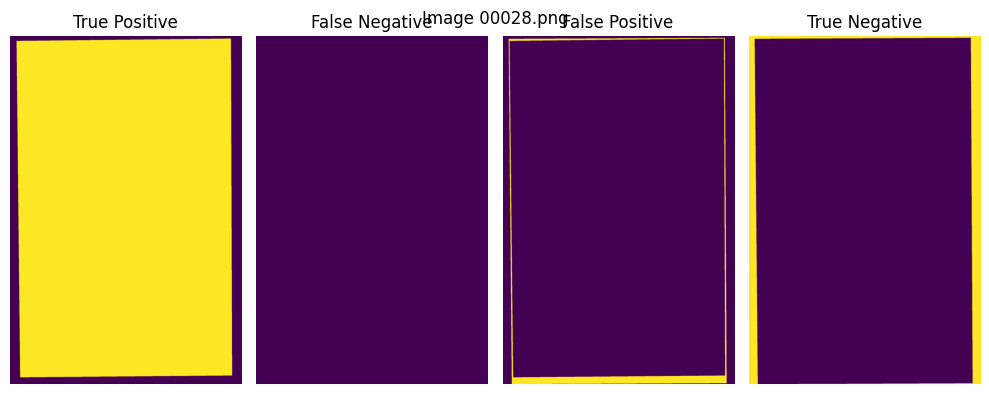

 97%|█████████▋| 29/30 [00:31<00:01,  1.08s/it]

Precision: 0.9644388897139473
Recall: 1.0
F_score: 0.9818975736673433
Hi Aleix
Hi Aleix


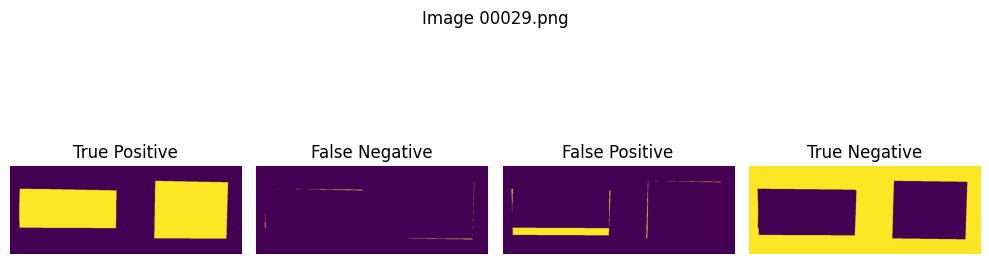

100%|██████████| 30/30 [00:32<00:00,  1.08s/it]

Precision: 0.9093766435422875
Recall: 0.9919140043434909
F_score: 0.9488537998706482
Average F_score : 0.9806007864520232
Average Precision : 0.9709960907306547
Average Recall : 0.991670855970484


In [7]:
score = 0
precision = 0
recall = 0

for i in tqdm(range(30)):
    img = cv2.imread(f"../data/qsd2_w3/{i:05d}.jpg", cv2.IMREAD_UNCHANGED)
    if has_impulse_noise(img):
        img = cv2.medianBlur(img, 3)
    correct_img = cv2.imread(f"../data/qsd2_w3/{i:05d}.png", cv2.IMREAD_UNCHANGED)
    
    masks = get_masks(img)
    result = masks[0]
    if len(masks) > 1:
        left_mask = masks[0]
        right_mask = masks[1]
        result = np.column_stack([left_mask, right_mask])
    
    TP = np.sum(correct_img & result)
    FN = np.sum(correct_img & (255 - result))
    FP = np.sum((255 - correct_img) & result)
    TN = np.sum((255 - correct_img) & (255 - result))
    
    f, ax = plt.subplots(1, 4, figsize=(10, 8))
    f.suptitle(f"Image {i:05d}.png")
    plt.axis('off')
    ax[0].imshow(correct_img & result)
    ax[0].axis('off')
    ax[0].set_title("True Positive")
    
    ax[1].imshow(correct_img & (255 - result))
    ax[1].axis('off')
    ax[1].set_title("False Negative")
    
    ax[2].imshow((255 - correct_img) & result)
    ax[2].axis('off')
    ax[2].set_title("False Positive")
    
    ax[3].imshow((255 - correct_img) & (255 - result))
    ax[3].axis('off')
    ax[3].set_title("True Negative")
    
    plt.tight_layout(rect=[0, 0, 1, 1.5])
    
    plt.show()
    
    
    P = TP / (TP + FP)
    R = TP / (TP + FN)
    F_score = 2*(P*R/(P + R))
    
    score = score + F_score
    precision += P
    recall += R
    
    print(f"Precision: {P}\nRecall: {R}\nF_score: {F_score}")
    
print(f"Average F_score : {score/30}")
print(f"Average Precision : {precision/30}")
print(f"Average Recall : {recall/30}")